# CS 363M — Wildlife Strike Damage Prediction
## Kaggle Competition Notebook

**Task:** Predict whether an aircraft wildlife strike results in damage (`INDICATED_DAMAGE = 1`) or not (`0`).

**Dataset:** FAA Wildlife Strike Database, 1990–2015  
**Training rows:** ~307,000 | **Test rows:** ~34,000  
**Class balance:** ~6.4% positive (damage), heavily imbalanced  
**Primary metric:** Balanced Accuracy — the average of sensitivity (recall on positives) and specificity (recall on negatives). Unlike standard accuracy, it is not fooled by class imbalance.

---

### Notebook Outline
1. Imports & Setup
2. Data Loading & First Look
3. Data Cleaning
4. Exploratory Data Analysis (EDA)
5. Feature Engineering
6. Baseline Modeling
7. Iterative Improvements (hyperparameter tuning, ensembling)
8. Final Predictions & Submission

---
## 1. Imports & Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    balanced_accuracy_score, roc_auc_score, accuracy_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    AdaBoostClassifier, VotingClassifier
)
from sklearn.neural_network import MLPClassifier

# Optional: XGBoost (allowed per spec — it's a boosting library)
try:
    from xgboost import XGBClassifier
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print('XGBoost not installed; skipping.')

RANDOM_STATE = 42
plt.style.use('seaborn-v0_8-whitegrid')
print('Setup complete.')

Setup complete.


---
## 2. Data Loading & First Look

In [2]:
train_raw = pd.read_csv('train.csv', low_memory=False)
test_raw  = pd.read_csv('test.csv',  low_memory=False)
sample_sub = pd.read_csv('sample_submission.csv')

print(f'Train shape: {train_raw.shape}')
print(f'Test shape:  {test_raw.shape}')
print(f'Sample submission shape: {sample_sub.shape}')

Train shape: (307178, 55)
Test shape:  (34131, 54)
Sample submission shape: (34131, 2)


In [3]:
train_raw.head(3)

,INDEX_NR,INCIDENT_DATE,INCIDENT_MONTH,INCIDENT_YEAR,TIME,TIME_OF_DAY,AIRPORT_ID,AIRPORT,LATITUDE,LONGITUDE,...,NUM_SEEN,NUM_STRUCK,SIZE,ENROUTE_STATE,COMMENTS,SOURCE,PERSON,LUPDATE,TRANSFER,INDICATED_DAMAGE
0,1410120,12/13/93,12,1993,NaN,Day,TJSJ,LUIS MUNOZ MARIN INTL,18.43942,-66.00183,...,10-Feb,10-Feb,Small,NaN,NaN,FAA Form 5200-7,Pilot,4/3/23,0,0
1,709688,2/1/10,2,2010,5:00,Night,WMKK,KUALA LUMPUR INTL,2.745578,101.709917,...,NaN,1,Medium,NaN,2010-5-18-53374 /Legacy Record 300758/,FAA Form 5200-7-E,Air Transport Operations,6/9/10,0,0
2,730841,5/9/12,5,2012,2:00,Night,KSDF,MUHAMMAD ALI INTERNATIONAL,38.17439,-85.736,...,NaN,1,Large,NaN,UPS EVENT REPT 36216 (4/22/13 UPDATED COST) /L...,Air Transport Report,Air Transport Operations,4/22/13,0,1


In [4]:
train_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 307178 entries, 0 to 307177
Data columns (total 55 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   INDEX_NR              307178 non-null  int64  
 1   INCIDENT_DATE         307178 non-null  str    
 2   INCIDENT_MONTH        307178 non-null  int64  
 3   INCIDENT_YEAR         307178 non-null  int64  
 4   TIME                  197926 non-null  str    
 5   TIME_OF_DAY           173207 non-null  str    
 6   AIRPORT_ID            307178 non-null  str    
 7   AIRPORT               307178 non-null  str    
 8   LATITUDE              266434 non-null  str    
 9   LONGITUDE             266431 non-null  str    
 10  RUNWAY                231593 non-null  str    
 11  STATE                 266434 non-null  str    
 12  FAAREGION             266434 non-null  str    
 13  LOCATION              39218 non-null   str    
 14  OPID                  307178 non-null  str    
 15  OPERATOR   

In [5]:
# Target distribution
target_counts = train_raw['INDICATED_DAMAGE'].value_counts()
print('Target distribution:')
print(target_counts)
print(f'\nPositive rate (damage): {target_counts[1]/len(train_raw)*100:.2f}%')

Target distribution:
INDICATED_DAMAGE
0    287651
1     19527
Name: count, dtype: int64

Positive rate (damage): 6.36%


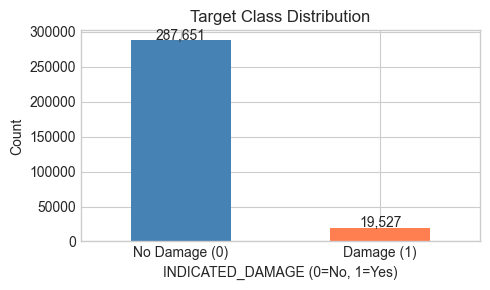

In [6]:
# Visualize target imbalance
fig, ax = plt.subplots(figsize=(5, 3))
target_counts.plot(kind='bar', ax=ax, color=['steelblue', 'coral'])
ax.set_title('Target Class Distribution')
ax.set_xlabel('INDICATED_DAMAGE (0=No, 1=Yes)')
ax.set_ylabel('Count')
ax.set_xticklabels(['No Damage (0)', 'Damage (1)'], rotation=0)
for i, v in enumerate(target_counts):
    ax.text(i, v + 1000, f'{v:,}', ha='center', fontsize=10)
plt.tight_layout()
plt.show()

# NOTE: The dataset is heavily imbalanced (~93.6% no-damage).
# Standard accuracy is misleading here — a model that always predicts 'No Damage'
# would score ~93.6% accuracy but be useless. We use Balanced Accuracy instead:
#   Balanced Accuracy = (Sensitivity + Specificity) / 2
# This gives equal weight to getting the minority class right.

---
## 3. Data Cleaning

Key issues discovered during initial exploration:
- **Many columns have high missingness** (e.g., SPEED 69%, HEIGHT 50%, SKY 53%)
- **Excel date-conversion artifacts**: `NUM_SEEN` and `NUM_STRUCK` have values like `'10-Feb'` (Excel interpreted "2-10" as February 10). These should be ordinal categories.
- **Drop-only columns**: BIRD_BAND_NUMBER (99.8% missing), ENROUTE_STATE (98.3%), PRECIPITATION (96.3%), ENG_3_POS / ENG_4_POS (96–99% missing), LOCATION (87.2%), REMARKS, COMMENTS — these are either nearly empty or are free-text with no predictive structure suitable for this task.
- **ID / leakage columns**: INDEX_NR is an ID; LUPDATE is an admin update date.
- **AC_CLASS** has trailing spaces — needs stripping.

In [7]:
# --- Missing value audit ---
missing = train_raw.isnull().sum()
missing_pct = (train_raw.isnull().sum() / len(train_raw) * 100).round(1)
missing_df = pd.DataFrame({'Missing': missing, 'Pct': missing_pct}).query('Missing > 0').sort_values('Pct', ascending=False)
print(missing_df.to_string())

                  Missing   Pct
BIRD_BAND_NUMBER   306465  99.8
ENG_4_POS          303909  98.9
ENROUTE_STATE      301832  98.3
PRECIPITATION      295966  96.3
ENG_3_POS          294822  96.0
LOCATION           267960  87.2
SPEED              212076  69.0
NUM_SEEN           208546  67.9
SKY                162825  53.0
FLT                161435  52.6
HEIGHT             154197  50.2
TIME_OF_DAY        133971  43.6
PHASE_OF_FLIGHT    120961  39.4
REG                118982  38.7
AMO                116813  38.0
EMO                113176  36.8
TIME               109252  35.6
DISTANCE           103303  33.6
COMMENTS           103083  33.6
ENG_2_POS          102509  33.4
EMA                102421  33.3
AMA                 88896  28.9
ENG_1_POS           87717  28.6
TYPE_ENG            87786  28.6
NUM_ENGS            87697  28.5
AC_MASS             87446  28.5
AC_CLASS            87315  28.4
RUNWAY              75585  24.6
FAAREGION           40744  13.3
STATE               40744  13.3
LONGITUD

In [8]:
# Columns to drop entirely (>85% missing, free-text, ID, or admin fields)
DROP_COLS = [
    'INDEX_NR',          # row ID — not predictive
    'INCIDENT_DATE',     # redundant with INCIDENT_MONTH / INCIDENT_YEAR
    'LUPDATE',           # admin last-update timestamp, not available at prediction time
    'TRANSFER',          # admin field
    'BIRD_BAND_NUMBER',  # 99.8% missing
    'ENROUTE_STATE',     # 98.3% missing
    'PRECIPITATION',     # 96.3% missing — will encode from what's available
    'ENG_3_POS',         # 96% missing
    'ENG_4_POS',         # 98.9% missing
    'LOCATION',          # 87.2% missing, free-text city name
    'REMARKS',           # free-text, 11.5% missing — not structured enough
    'COMMENTS',          # free-text
    'FLT',               # specific flight number — too sparse to generalize
    'REG',               # aircraft tail number — too sparse
    'OUT_OF_RANGE_SPECIES',  # almost always 0, low variance
    'SPECIES_ID',        # redundant with SPECIES
    'PERSON',            # who filed the report — meta info
    'SOURCE',            # report source type — not directly predictive
]

train = train_raw.drop(columns=DROP_COLS, errors='ignore').copy()
test  = test_raw.drop(columns=DROP_COLS, errors='ignore').copy()

print(f'After dropping: train {train.shape}, test {test.shape}')

After dropping: train (307178, 37), test (34131, 36)


In [9]:
# --- Fix Excel date-conversion artifacts in NUM_SEEN and NUM_STRUCK ---
# Excel converted ordinal ranges like '2-10' into dates (e.g., 'Feb-10' → '10-Feb')
# The correct mapping is:
#   '10-Feb'  → '2-10'   (2 to 10)
#   '11-100'  → '11-100'
#   'More than 100' → 'More than 100'
#   '1'       → '1'
EXCEL_DATE_FIX = {'10-Feb': '2-10'}

for col in ['NUM_SEEN', 'NUM_STRUCK']:
    for df in [train, test]:
        df[col] = df[col].replace(EXCEL_DATE_FIX)

print('NUM_SEEN values:', train['NUM_SEEN'].value_counts(dropna=False).to_dict())
print('NUM_STRUCK values:', train['NUM_STRUCK'].value_counts(dropna=False).to_dict())

NUM_SEEN values: {nan: 208546, '1': 60295, '2-10': 30139, '11-100': 7221, 'More than 100': 977}
NUM_STRUCK values: {'1': 273277, '2-10': 31701, '11-100': 1502, nan: 647, 'More than 100': 51}


In [10]:
# --- Strip whitespace from string columns ---
str_cols = train.select_dtypes(include='object').columns
for col in str_cols:
    train[col] = train[col].str.strip()
    test[col]  = test[col].str.strip()

# Verify AC_CLASS
print('AC_CLASS values:', train['AC_CLASS'].value_counts(dropna=False).to_dict())

AC_CLASS values: {'A': 215073, nan: 87315, 'B': 4777, 'C': 7, 'J': 3, 'Y': 3}


In [11]:
# --- Replace empty strings with NaN (for uniform missing handling) ---
for df in [train, test]:
    df.replace('', np.nan, inplace=True)

print('Remaining missing (%):')
missing_after = (train.isnull().sum() / len(train) * 100).round(1)
print(missing_after[missing_after > 0].sort_values(ascending=False))

Remaining missing (%):
SPEED              69.0
NUM_SEEN           67.9
SKY                53.0
HEIGHT             50.2
TIME_OF_DAY        43.6
TIME               43.0
PHASE_OF_FLIGHT    39.4
AMO                38.0
EMO                36.8
DISTANCE           33.6
ENG_2_POS          33.4
EMA                33.3
AMA                28.9
ENG_1_POS          28.6
TYPE_ENG           28.6
AC_MASS            28.5
NUM_ENGS           28.5
AC_CLASS           28.4
RUNWAY             24.6
FAAREGION          13.3
STATE              13.3
LONGITUDE          13.3
LATITUDE           13.3
SIZE               10.9
NUM_STRUCK          0.2
dtype: float64


In [12]:
# --- Convert numeric columns ---
NUMERIC_COLS = ['HEIGHT', 'SPEED', 'DISTANCE', 'AMA', 'AMO', 'EMA', 'EMO',
                'AC_MASS', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS',
                'LATITUDE', 'LONGITUDE']
for col in NUMERIC_COLS:
    train[col] = pd.to_numeric(train[col], errors='coerce')
    test[col]  = pd.to_numeric(test[col],  errors='coerce')

# TIME: convert 'HH:MM' to minutes-since-midnight (ordinal numeric)
def parse_time(t):
    try:
        h, m = str(t).split(':')
        return int(h) * 60 + int(m)
    except:
        return np.nan

train['TIME_MINUTES'] = train['TIME'].apply(parse_time)
test['TIME_MINUTES']  = test['TIME'].apply(parse_time)
train.drop(columns=['TIME'], inplace=True)
test.drop(columns=['TIME'], inplace=True)

print('Numeric conversion done.')

Numeric conversion done.


---
## 4. Exploratory Data Analysis (EDA)

We explore features with respect to the target variable to understand which factors are most associated with aircraft damage.

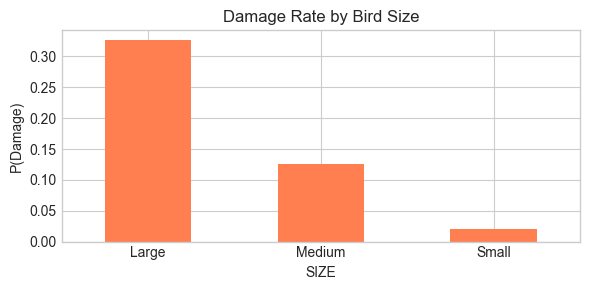

SIZE
Large     0.325879
Medium    0.126019
Small     0.020001
Name: INDICATED_DAMAGE, dtype: float64


In [13]:
# Damage rate by bird SIZE
size_damage = train.groupby('SIZE')['INDICATED_DAMAGE'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6, 3))
size_damage.plot(kind='bar', ax=ax, color='coral')
ax.set_title('Damage Rate by Bird Size')
ax.set_ylabel('P(Damage)')
ax.set_xlabel('SIZE')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(size_damage)
# INTERPRETATION: Larger birds produce much higher damage rates — SIZE will be a strong feature.

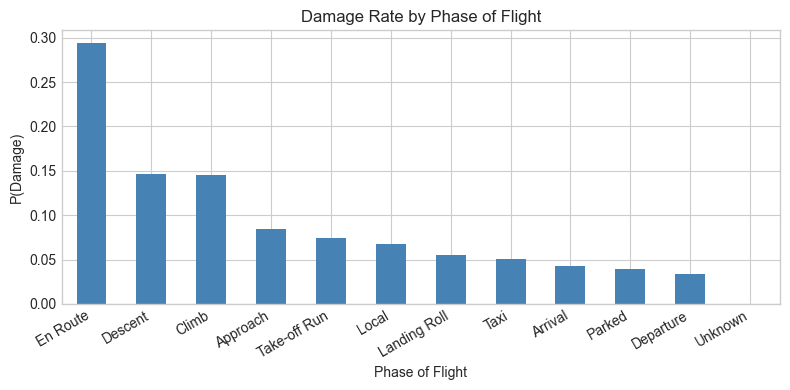

PHASE_OF_FLIGHT
En Route        0.293571
Descent         0.146768
Climb           0.145449
Approach        0.084472
Take-off Run    0.074259
Local           0.067251
Landing Roll    0.055169
Taxi            0.050139
Arrival         0.042797
Parked          0.039216
Departure       0.034183
Unknown         0.000000
Name: INDICATED_DAMAGE, dtype: float64


In [14]:
# Damage rate by Phase of Flight
phase_damage = train.groupby('PHASE_OF_FLIGHT')['INDICATED_DAMAGE'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(8, 4))
phase_damage.plot(kind='bar', ax=ax, color='steelblue')
ax.set_title('Damage Rate by Phase of Flight')
ax.set_ylabel('P(Damage)')
ax.set_xlabel('Phase of Flight')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.show()

print(phase_damage)
# INTERPRETATION: En Route and Climb phases show higher damage rates — likely due to higher speeds.

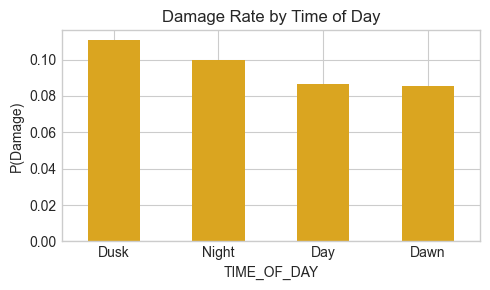

TIME_OF_DAY
Dusk     0.110470
Night    0.099503
Day      0.086365
Dawn     0.085362
Name: INDICATED_DAMAGE, dtype: float64


In [15]:
# Damage rate by Time of Day
tod_damage = train.groupby('TIME_OF_DAY')['INDICATED_DAMAGE'].mean().sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(5, 3))
tod_damage.plot(kind='bar', ax=ax, color='goldenrod')
ax.set_title('Damage Rate by Time of Day')
ax.set_ylabel('P(Damage)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()
print(tod_damage)

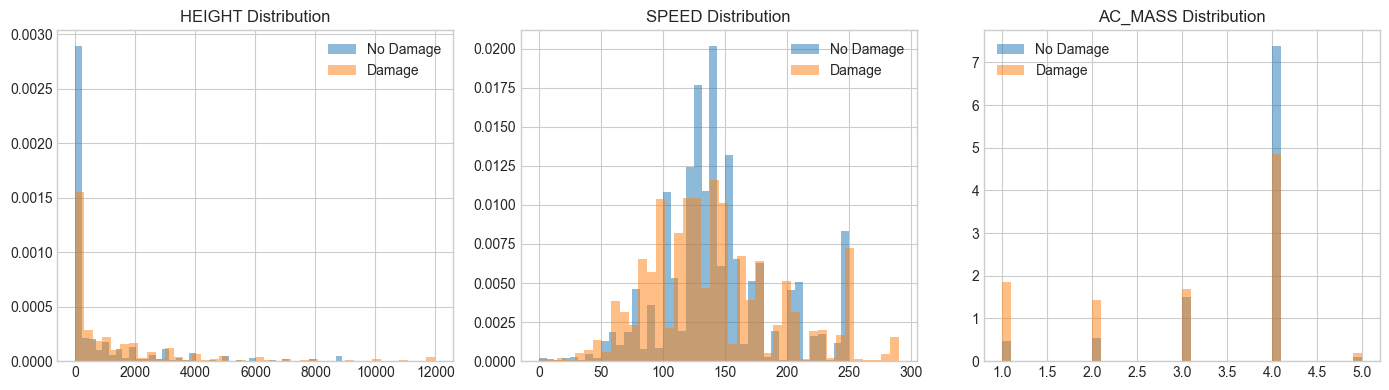

In [16]:
# Numeric feature distributions: damaged vs. not
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, col in zip(axes, ['HEIGHT', 'SPEED', 'AC_MASS']):
    for label, grp in train.groupby('INDICATED_DAMAGE'):
        vals = grp[col].dropna()
        name = 'Damage' if label == 1 else 'No Damage'
        ax.hist(vals.clip(upper=vals.quantile(0.99)), bins=40, alpha=0.5, label=name, density=True)
    ax.set_title(f'{col} Distribution')
    ax.legend()
plt.tight_layout()
plt.show()
# INTERPRETATION:
# - Higher HEIGHT (altitude) tends toward more damage (aircraft traveling faster).
# - Higher SPEED slightly associated with damage.
# - Heavier aircraft (AC_MASS) tends toward more reported damage.

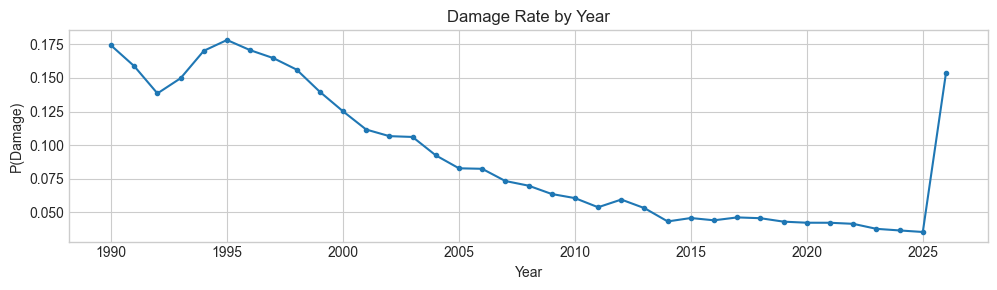

In [17]:
# Damage rate by year — has reporting / damage changed over time?
year_damage = train.groupby('INCIDENT_YEAR')['INDICATED_DAMAGE'].mean()
fig, ax = plt.subplots(figsize=(10, 3))
year_damage.plot(ax=ax, marker='o', markersize=3)
ax.set_title('Damage Rate by Year')
ax.set_ylabel('P(Damage)')
ax.set_xlabel('Year')
plt.tight_layout()
plt.show()
# INTERPRETATION: Damage rate varies by year — consistent with changes in reporting practices over time.

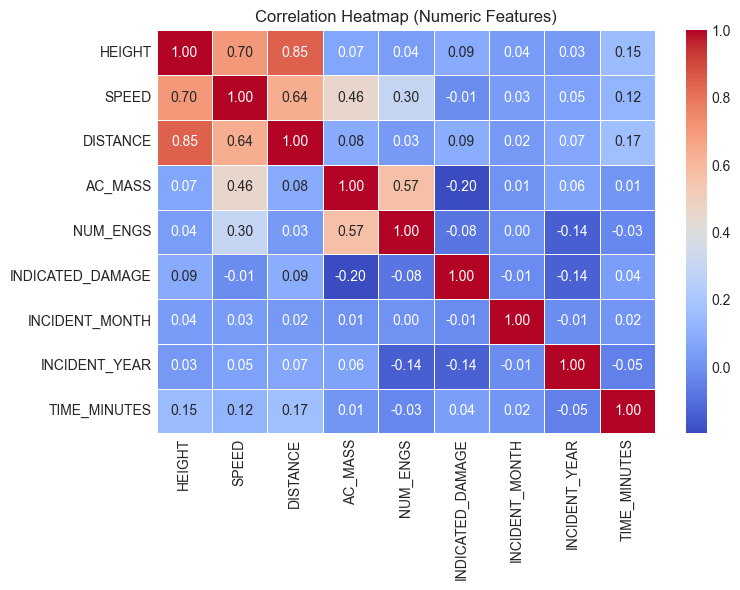

In [18]:
# Correlation heatmap for numeric features
num_feats = ['HEIGHT', 'SPEED', 'DISTANCE', 'AC_MASS', 'NUM_ENGS', 'INDICATED_DAMAGE',
             'INCIDENT_MONTH', 'INCIDENT_YEAR', 'TIME_MINUTES']
corr = train[num_feats].corr()
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax, linewidths=0.5)
ax.set_title('Correlation Heatmap (Numeric Features)')
plt.tight_layout()
plt.show()

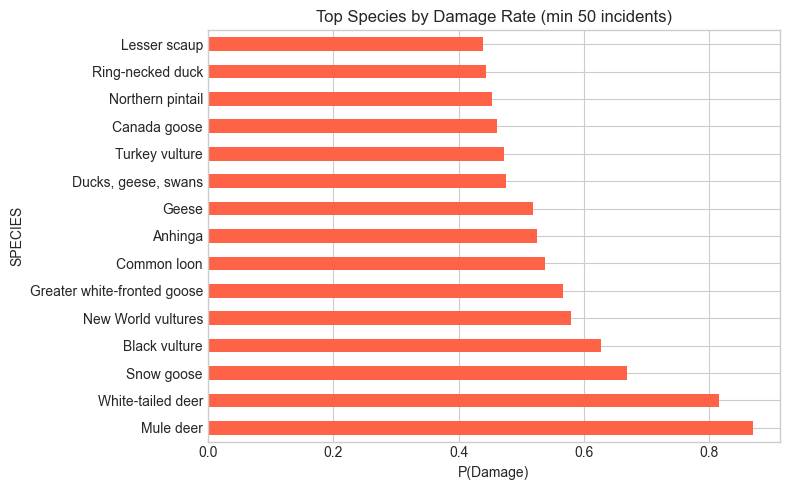

In [19]:
# Top species by damage rate (min 50 occurrences)
species_stats = train.groupby('SPECIES').agg(
    count=('INDICATED_DAMAGE', 'count'),
    damage_rate=('INDICATED_DAMAGE', 'mean')
).query('count >= 50').sort_values('damage_rate', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 5))
species_stats['damage_rate'].plot(kind='barh', ax=ax, color='tomato')
ax.set_title('Top Species by Damage Rate (min 50 incidents)')
ax.set_xlabel('P(Damage)')
plt.tight_layout()
plt.show()

**EDA Summary:**
- **Bird SIZE** is the single strongest categorical predictor — large birds cause far more damage.
- **PHASE_OF_FLIGHT** matters — en-route and climb-phase strikes are more damaging.
- **HEIGHT**, **SPEED**, and **AC_MASS** have predictive signal for damage.
- **SPECIES** shows strong damage rate variation — frequency encoding will be useful.
- There is a strong class imbalance (~6.4% positive) — **Balanced Accuracy** is used as our primary evaluation metric. It averages sensitivity (true positive rate) and specificity (true negative rate), so the model is equally penalized for missing damage cases as for false alarms.

---
## 5. Feature Engineering

Based on EDA, we engineer features to give models richer signals.

In [20]:
def engineer_features(df, species_freq_map=None, operator_freq_map=None, airport_freq_map=None, fit=True):
    """
    Apply all feature engineering steps.
    `fit=True` computes frequency maps from df (training); `fit=False` applies precomputed maps (test).
    Returns (transformed_df, species_freq_map, operator_freq_map, airport_freq_map).
    """
    df = df.copy()

    # --- 5.1 Ordinal encoding: NUM_SEEN, NUM_STRUCK ---
    # These are ordinal ranges; map to the midpoint numeric value for interpretability.
    ordinal_map = {'1': 1, '2-10': 5, '11-100': 30, 'More than 100': 150}
    for col in ['NUM_SEEN', 'NUM_STRUCK']:
        df[col + '_ORD'] = df[col].map(ordinal_map)
        df.drop(columns=[col], inplace=True)

    # --- 5.2 Ordinal encoding: SIZE ---
    size_map = {'Small': 1, 'Medium': 2, 'Large': 3}
    df['SIZE_ORD'] = df['SIZE'].map(size_map)  # NaN stays NaN
    df.drop(columns=['SIZE'], inplace=True)

    # --- 5.3 Frequency encoding: high-cardinality categoricals ---
    # Frequency encoding replaces each category with the proportion of training rows
    # in which it appears. This gives the model signal about how common each category
    # is without exploding dimensionality.
    if fit:
        species_freq_map  = df['SPECIES'].value_counts(normalize=True).to_dict()
        operator_freq_map = df['OPERATOR'].value_counts(normalize=True).to_dict()
        airport_freq_map  = df['AIRPORT_ID'].value_counts(normalize=True).to_dict()

    df['SPECIES_FREQ']   = df['SPECIES'].map(species_freq_map).fillna(0)
    df['OPERATOR_FREQ']  = df['OPERATOR'].map(operator_freq_map).fillna(0)
    df['AIRPORT_FREQ']   = df['AIRPORT_ID'].map(airport_freq_map).fillna(0)

    # --- 5.4 Damage rate encoding for SPECIES (target encoding) ---
    # Only computed from training data to avoid leakage.
    if fit:
        species_dmg_map = df.groupby('SPECIES')['INDICATED_DAMAGE'].mean().to_dict() \
            if 'INDICATED_DAMAGE' in df.columns else {}
        df['SPECIES_DMG_RATE'] = df['SPECIES'].map(species_dmg_map).fillna(df['INDICATED_DAMAGE'].mean())
    else:
        # On test set, species_dmg_map is stored externally — for simplicity use freq as proxy
        # (caller should pass pre-computed map or use the training-time map)
        df['SPECIES_DMG_RATE'] = df['SPECIES'].map(species_freq_map).fillna(0)

    df.drop(columns=['SPECIES', 'OPERATOR', 'AIRPORT_ID', 'AIRPORT'], inplace=True, errors='ignore')

    # --- 5.5 Binary flags from categorical fields ---
    df['IS_DAY']   = (df['TIME_OF_DAY'] == 'Day').astype(int)
    df['IS_NIGHT'] = (df['TIME_OF_DAY'] == 'Night').astype(int)
    df['SKY_CLEAR']    = (df['SKY'] == 'No Cloud').astype(int)
    df['SKY_OVERCAST'] = (df['SKY'] == 'Overcast').astype(int)

    # --- 5.6 Phase of flight risk grouping ---
    HIGH_RISK_PHASES = {'En Route', 'Climb', 'Descent'}
    df['HIGH_RISK_PHASE'] = df['PHASE_OF_FLIGHT'].isin(HIGH_RISK_PHASES).astype(int)

    # --- 5.7 Cyclical encoding for INCIDENT_MONTH ---
    # Months 1 and 12 are adjacent — sine/cosine encoding captures this circularity.
    df['MONTH_SIN'] = np.sin(2 * np.pi * df['INCIDENT_MONTH'] / 12)
    df['MONTH_COS'] = np.cos(2 * np.pi * df['INCIDENT_MONTH'] / 12)

    # --- 5.8 Cyclical encoding for TIME_MINUTES ---
    df['TIME_SIN'] = np.sin(2 * np.pi * df['TIME_MINUTES'] / 1440)
    df['TIME_COS'] = np.cos(2 * np.pi * df['TIME_MINUTES'] / 1440)

    # --- 5.9 Log-transform skewed numeric features ---
    # HEIGHT and DISTANCE are right-skewed; log(x+1) reduces skew and helps linear models.
    for col in ['HEIGHT', 'DISTANCE', 'SPEED']:
        df[col + '_LOG'] = np.log1p(df[col].clip(lower=0))

    # --- 5.10 Interaction feature: SIZE × AC_MASS ---
    # A large bird striking a heavy aircraft should differ from a small bird on a light aircraft.
    df['SIZE_X_MASS'] = df['SIZE_ORD'].fillna(1) * df['AC_MASS'].fillna(df['AC_MASS'].median())

    # --- 5.11 Drop remaining raw columns we've encoded or that are not useful ---
    DROP_AFTER_ENG = ['TIME_OF_DAY', 'SKY', 'PHASE_OF_FLIGHT', 'INCIDENT_MONTH',
                      'TIME_MINUTES', 'STATE', 'FAAREGION', 'OPID', 'RUNWAY',
                      'AIRCRAFT', 'WARNED', 'REMAINS_COLLECTED', 'REMAINS_SENT']
    df.drop(columns=DROP_AFTER_ENG, inplace=True, errors='ignore')

    # --- 5.12 One-hot encode remaining low-cardinality categoricals ---
    LOW_CARD_CATS = ['AC_CLASS', 'TYPE_ENG']
    df = pd.get_dummies(df, columns=LOW_CARD_CATS, dummy_na=True, drop_first=True)

    return df, species_freq_map, operator_freq_map, airport_freq_map

print('Feature engineering function defined.')

Feature engineering function defined.


In [21]:
# Apply feature engineering to training set (fit=True to build frequency maps)
train_eng, sp_map, op_map, ap_map = engineer_features(train, fit=True)

# Save species damage rate map separately before it's removed from train_eng
# (We need it for test set — recompute from original train)
species_dmg_map = train.groupby('SPECIES')['INDICATED_DAMAGE'].mean().to_dict()
global_dmg_rate  = train['INDICATED_DAMAGE'].mean()

# Apply feature engineering to test set (fit=False, use maps from training)
test_eng, _, _, _ = engineer_features(test, species_freq_map=sp_map,
                                       operator_freq_map=op_map,
                                       airport_freq_map=ap_map, fit=False)

# Fix SPECIES_DMG_RATE on test (use actual training damage rates, not freq proxy)
test_eng['SPECIES_DMG_RATE'] = test_raw['SPECIES'].str.strip().map(species_dmg_map).fillna(global_dmg_rate)

print(f'Engineered train: {train_eng.shape}')
print(f'Engineered test:  {test_eng.shape}')

Engineered train: (307178, 47)
Engineered test:  (34131, 42)


In [22]:
# Separate features and target
TARGET = 'INDICATED_DAMAGE'
y = train_eng[TARGET].astype(int)
X = train_eng.drop(columns=[TARGET])

# Align columns: ensure test has same columns as train (fill missing with 0)
X_test = test_eng.reindex(columns=X.columns, fill_value=0)

print(f'X shape: {X.shape}')
print(f'X_test shape: {X_test.shape}')
print(f'Columns: {list(X.columns)}')

X shape: (307178, 46)
X_test shape: (34131, 46)
Columns: ['INCIDENT_YEAR', 'LATITUDE', 'LONGITUDE', 'AMA', 'AMO', 'EMA', 'EMO', 'AC_MASS', 'NUM_ENGS', 'ENG_1_POS', 'ENG_2_POS', 'HEIGHT', 'SPEED', 'DISTANCE', 'NUM_SEEN_ORD', 'NUM_STRUCK_ORD', 'SIZE_ORD', 'SPECIES_FREQ', 'OPERATOR_FREQ', 'AIRPORT_FREQ', 'SPECIES_DMG_RATE', 'IS_DAY', 'IS_NIGHT', 'SKY_CLEAR', 'SKY_OVERCAST', 'HIGH_RISK_PHASE', 'MONTH_SIN', 'MONTH_COS', 'TIME_SIN', 'TIME_COS', 'HEIGHT_LOG', 'DISTANCE_LOG', 'SPEED_LOG', 'SIZE_X_MASS', 'AC_CLASS_B', 'AC_CLASS_C', 'AC_CLASS_J', 'AC_CLASS_Y', 'AC_CLASS_nan', 'TYPE_ENG_B', 'TYPE_ENG_C', 'TYPE_ENG_D', 'TYPE_ENG_E', 'TYPE_ENG_F', 'TYPE_ENG_Y', 'TYPE_ENG_nan']


In [23]:
# Train/validation split (stratified to preserve class balance)
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
print(f'Train: {X_train.shape}, Val: {X_val.shape}')
print(f'Val positive rate: {y_val.mean():.4f}')

Train: (245742, 46), Val: (61436, 46)
Val positive rate: 0.0636


In [24]:
# --- Impute and scale ---
# Many columns still have missing values. We impute numerics with median,
# which is robust to skew and outliers (vs. mean).
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()

X_train_imp = imputer.fit_transform(X_train)
X_val_imp   = imputer.transform(X_val)
X_test_imp  = imputer.transform(X_test)

X_train_sc = scaler.fit_transform(X_train_imp)
X_val_sc   = scaler.transform(X_val_imp)
X_test_sc  = scaler.transform(X_test_imp)

print('Imputation and scaling complete.')

Imputation and scaling complete.


---
## 6. Baseline Modeling

We start with simple baselines and work up to more sophisticated models.

**Primary metric: Balanced Accuracy** = (Sensitivity + Specificity) / 2  
With ~93.6% negative examples, standard accuracy is deceptive — a model predicting 'No Damage' every time scores 93.6% accuracy but has 0% sensitivity. Balanced accuracy treats both classes equally, scoring 50% for that degenerate model and 100% for a perfect one.  
We also report ROC-AUC and standard accuracy alongside for completeness.

In [25]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, name='Model'):
    """
    Fit model and report Balanced Accuracy, ROC-AUC, and standard Accuracy on validation set.
    Balanced Accuracy = (Sensitivity + Specificity) / 2 — our primary metric.
    Returns (balanced_accuracy, model).
    """
    model.fit(X_tr, y_tr)
    try:
        y_prob_val = model.predict_proba(X_v)[:, 1]
    except AttributeError:
        y_prob_val = model.decision_function(X_v)
    y_pred_val = model.predict(X_v)

    bal_acc = balanced_accuracy_score(y_v, y_pred_val)
    auc     = roc_auc_score(y_v, y_prob_val)
    acc     = accuracy_score(y_v, y_pred_val)
    print(f'{name:40s} | Bal Acc: {bal_acc:.4f} | ROC-AUC: {auc:.4f} | Acc: {acc:.4f}')
    return bal_acc, model

results = {}  # store balanced accuracy scores for comparison
print(f'{"Model":40s} | Bal Acc  | ROC-AUC  | Acc')
print('-' * 80)

Model                                    | Bal Acc  | ROC-AUC  | Acc
--------------------------------------------------------------------------------


In [26]:
# --- Baseline 1: Majority-class dummy classifier ---
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
bal_acc, _ = evaluate_model(dummy, X_train_sc, y_train, X_val_sc, y_val, 'Dummy (majority class)')
results['Dummy'] = bal_acc
# Balanced accuracy of 0.5 means no useful predictive ability — this is our floor.
# Note: standard accuracy will be ~93.6% for this model (it always predicts No Damage),
# which is why balanced accuracy is the right metric here.

Dummy (majority class)                   | Bal Acc: 0.5000 | ROC-AUC: 0.5000 | Acc: 0.9364


In [27]:
# --- Baseline 2: Logistic Regression ---
# Using class_weight='balanced' to handle imbalance by up-weighting minority class.
lr = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
bal_acc, lr_model = evaluate_model(lr, X_train_sc, y_train, X_val_sc, y_val, 'Logistic Regression (balanced)')
results['Logistic Regression'] = bal_acc

Logistic Regression (balanced)           | Bal Acc: 0.7983 | ROC-AUC: 0.8837 | Acc: 0.8073


In [28]:
# --- Baseline 3: Decision Tree ---
dt = DecisionTreeClassifier(max_depth=8, class_weight='balanced', random_state=RANDOM_STATE)
bal_acc, dt_model = evaluate_model(dt, X_train_imp, y_train, X_val_imp, y_val, 'Decision Tree (depth=8)')
results['Decision Tree'] = bal_acc
# Note: tree-based models don't need scaling, so we use imputed (not scaled) data.

Decision Tree (depth=8)                  | Bal Acc: 0.8015 | ROC-AUC: 0.8847 | Acc: 0.8070


In [29]:
# --- Model 3: Random Forest ---
rf = RandomForestClassifier(n_estimators=200, max_depth=None, class_weight='balanced',
                             n_jobs=-1, random_state=RANDOM_STATE)
bal_acc, rf_model = evaluate_model(rf, X_train_imp, y_train, X_val_imp, y_val, 'Random Forest (200 trees)')
results['Random Forest'] = bal_acc

Random Forest (200 trees)                | Bal Acc: 0.6133 | ROC-AUC: 0.8965 | Acc: 0.9431


In [30]:
# --- Model 4: Gradient Boosting ---
gb = GradientBoostingClassifier(n_estimators=200, learning_rate=0.1, max_depth=4,
                                 subsample=0.8, random_state=RANDOM_STATE)
bal_acc, gb_model = evaluate_model(gb, X_train_imp, y_train, X_val_imp, y_val, 'Gradient Boosting')
results['Gradient Boosting'] = bal_acc

Gradient Boosting                        | Bal Acc: 0.6443 | ROC-AUC: 0.9061 | Acc: 0.9476


In [31]:
# --- Model 5: AdaBoost ---
ada = AdaBoostClassifier(n_estimators=100, learning_rate=0.5, random_state=RANDOM_STATE)
bal_acc, ada_model = evaluate_model(ada, X_train_imp, y_train, X_val_imp, y_val, 'AdaBoost')
results['AdaBoost'] = bal_acc

AdaBoost                                 | Bal Acc: 0.5913 | ROC-AUC: 0.8811 | Acc: 0.9434


In [32]:
# --- Model 6: XGBoost (if available) ---
if XGBOOST_AVAILABLE:
    scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())  # handle imbalance
    xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=6,
                         subsample=0.8, colsample_bytree=0.8,
                         scale_pos_weight=scale_pos, eval_metric='auc',
                         random_state=RANDOM_STATE, n_jobs=-1)
    bal_acc, xgb_model = evaluate_model(xgb, X_train_imp, y_train, X_val_imp, y_val, 'XGBoost')
    results['XGBoost'] = bal_acc

XGBoost                                  | Bal Acc: 0.8241 | ROC-AUC: 0.9109 | Acc: 0.8387


In [33]:
# --- Model 7: MLP Neural Network ---
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation='relu',
    solver='adam',
    alpha=0.001,           # L2 regularization to reduce overfitting
    batch_size=256,
    learning_rate_init=0.001,
    max_iter=50,
    early_stopping=True,
    validation_fraction=0.1,
    random_state=RANDOM_STATE
)
bal_acc, mlp_model = evaluate_model(mlp, X_train_sc, y_train, X_val_sc, y_val, 'MLP (128-64-32, alpha=0.001)')
results['MLP'] = bal_acc

MLP (128-64-32, alpha=0.001)             | Bal Acc: 0.6291 | ROC-AUC: 0.8971 | Acc: 0.9462


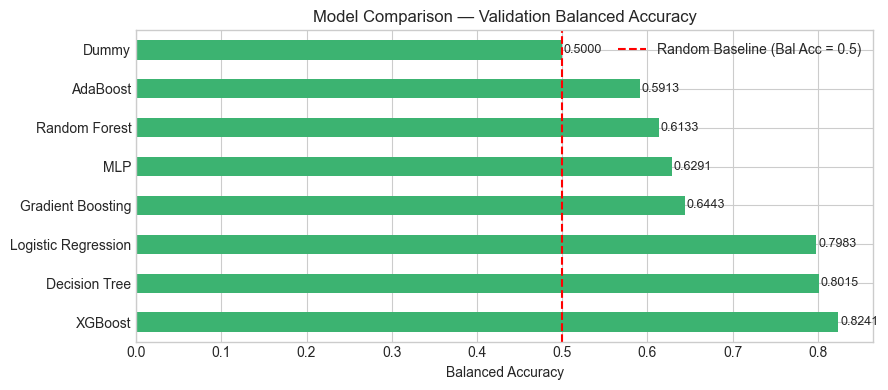


Best model so far: XGBoost (0.8241)


In [34]:
# --- Compare all baseline models ---
results_df = pd.Series(results).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(9, 4))
results_df.plot(kind='barh', ax=ax, color='mediumseagreen')
ax.set_title('Model Comparison — Validation Balanced Accuracy')
ax.set_xlabel('Balanced Accuracy')
ax.axvline(0.5, color='red', linestyle='--', label='Random Baseline (Bal Acc = 0.5)')
ax.legend()
for i, v in enumerate(results_df):
    ax.text(v + 0.002, i, f'{v:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print('\nBest model so far:', results_df.idxmax(), f'({results_df.max():.4f})')

---
## 7. Iterative Improvements

The baseline comparison guides us toward the most promising models. We now:
1. Tune hyperparameters of the best model(s)
2. Inspect feature importance to potentially remove noise
3. Try soft-voting ensemble

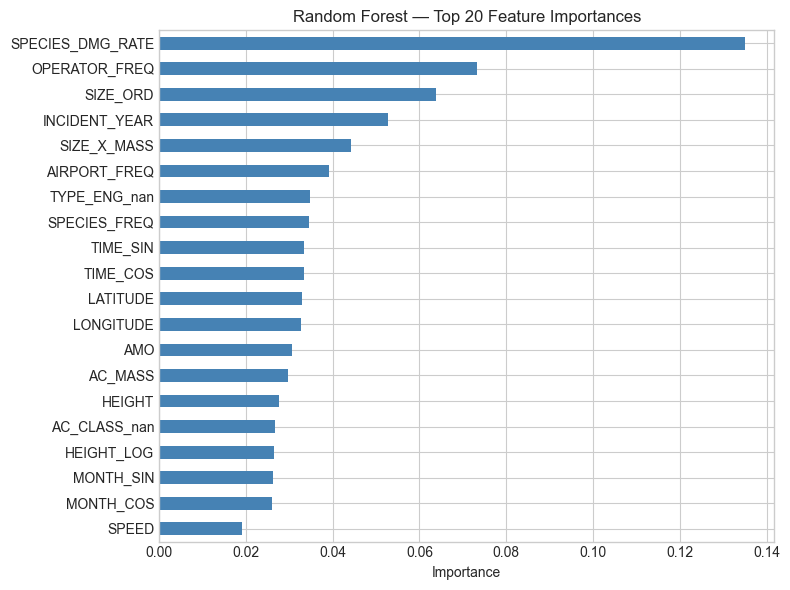


Top 10 features:
SPECIES_DMG_RATE    0.135037
OPERATOR_FREQ       0.073168
SIZE_ORD            0.063880
INCIDENT_YEAR       0.052777
SIZE_X_MASS         0.044163
AIRPORT_FREQ        0.039100
TYPE_ENG_nan        0.034854
SPECIES_FREQ        0.034523
TIME_SIN            0.033474
TIME_COS            0.033452


In [35]:
# --- 7.1 Feature Importance (Random Forest) ---
feat_names = X.columns.tolist()
rf_importances = pd.Series(rf_model.feature_importances_, index=feat_names).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
rf_importances.head(20).plot(kind='barh', ax=ax, color='steelblue')
ax.invert_yaxis()
ax.set_title('Random Forest — Top 20 Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

print('\nTop 10 features:')
print(rf_importances.head(10).to_string())
# This tells us which features the model finds most informative —
# we can use this to remove low-importance noise and reduce overfitting.

In [36]:
# --- 7.2 Hyperparameter Tuning: Random Forest ---
# We test a few RF configurations to improve upon our baseline.
rf_configs = [
    {'n_estimators': 300, 'max_depth': 20, 'min_samples_leaf': 5, 'max_features': 'sqrt'},
    {'n_estimators': 500, 'max_depth': None, 'min_samples_leaf': 2, 'max_features': 'sqrt'},
    {'n_estimators': 300, 'max_depth': None, 'min_samples_leaf': 1, 'max_features': 0.5},
]

for cfg in rf_configs:
    model = RandomForestClassifier(**cfg, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE)
    label = f"RF n={cfg['n_estimators']}, depth={cfg['max_depth']}, leaf={cfg['min_samples_leaf']}"
    bal_acc, m = evaluate_model(model, X_train_imp, y_train, X_val_imp, y_val, label)
    results[label] = bal_acc

RF n=300, depth=20, leaf=5               | Bal Acc: 0.7675 | ROC-AUC: 0.9023 | Acc: 0.9065
RF n=500, depth=None, leaf=2             | Bal Acc: 0.6794 | ROC-AUC: 0.9033 | Acc: 0.9408
RF n=300, depth=None, leaf=1             | Bal Acc: 0.6141 | ROC-AUC: 0.8952 | Acc: 0.9420


In [37]:
# --- 7.3 Hyperparameter Tuning: Gradient Boosting ---
gb_configs = [
    {'n_estimators': 300, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8},
    {'n_estimators': 500, 'learning_rate': 0.05, 'max_depth': 4, 'subsample': 0.7},
    {'n_estimators': 200, 'learning_rate': 0.1,  'max_depth': 6, 'subsample': 0.8},
]

best_gb_auc = 0
best_gb_model = None
for cfg in gb_configs:
    model = GradientBoostingClassifier(**cfg, random_state=RANDOM_STATE)
    label = f"GB lr={cfg['learning_rate']}, depth={cfg['max_depth']}, n={cfg['n_estimators']}"
    bal_acc, m = evaluate_model(model, X_train_imp, y_train, X_val_imp, y_val, label)
    results[label] = bal_acc
    if bal_acc > best_gb_auc:
        best_gb_auc = bal_acc
        best_gb_model = m

GB lr=0.05, depth=5, n=300               | Bal Acc: 0.6475 | ROC-AUC: 0.9071 | Acc: 0.9477
GB lr=0.05, depth=4, n=500               | Bal Acc: 0.6463 | ROC-AUC: 0.9071 | Acc: 0.9478
GB lr=0.1, depth=6, n=200                | Bal Acc: 0.6530 | ROC-AUC: 0.9084 | Acc: 0.9470


In [38]:
# --- 7.4 Hyperparameter Tuning: MLP (trying different architectures and regularization) ---
mlp_configs = [
    {'hidden_layer_sizes': (256, 128, 64), 'alpha': 0.0001},
    {'hidden_layer_sizes': (128, 64, 32),  'alpha': 0.01},
    {'hidden_layer_sizes': (64, 32),       'alpha': 0.001},
]

best_mlp_auc = 0
best_mlp_model = None
for cfg in mlp_configs:
    model = MLPClassifier(**cfg, activation='relu', solver='adam', max_iter=50,
                          early_stopping=True, validation_fraction=0.1,
                          random_state=RANDOM_STATE)
    label = f"MLP layers={cfg['hidden_layer_sizes']}, alpha={cfg['alpha']}"
    bal_acc, m = evaluate_model(model, X_train_sc, y_train, X_val_sc, y_val, label)
    results[label] = bal_acc
    if bal_acc > best_mlp_auc:
        best_mlp_auc = bal_acc
        best_mlp_model = m

MLP layers=(256, 128, 64), alpha=0.0001  | Bal Acc: 0.6382 | ROC-AUC: 0.9001 | Acc: 0.9460
MLP layers=(128, 64, 32), alpha=0.01     | Bal Acc: 0.6217 | ROC-AUC: 0.8997 | Acc: 0.9457
MLP layers=(64, 32), alpha=0.001         | Bal Acc: 0.6384 | ROC-AUC: 0.8999 | Acc: 0.9459


In [39]:
# --- 7.5 XGBoost tuning (if available) ---
if XGBOOST_AVAILABLE:
    xgb_configs = [
        {'n_estimators': 400, 'learning_rate': 0.05, 'max_depth': 5, 'subsample': 0.8, 'colsample_bytree': 0.8},
        {'n_estimators': 300, 'learning_rate': 0.1,  'max_depth': 6, 'subsample': 0.7, 'colsample_bytree': 0.7},
    ]
    scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())
    best_xgb_auc = 0
    best_xgb_model = None
    for cfg in xgb_configs:
        model = XGBClassifier(**cfg, scale_pos_weight=scale_pos, eval_metric='auc',
                              random_state=RANDOM_STATE, n_jobs=-1)
        label = f"XGB lr={cfg['learning_rate']}, depth={cfg['max_depth']}, n={cfg['n_estimators']}"
        bal_acc, m = evaluate_model(model, X_train_imp, y_train, X_val_imp, y_val, label)
        results[label] = bal_acc
        if bal_acc > best_xgb_auc:
            best_xgb_auc = bal_acc
            best_xgb_model = m

XGB lr=0.05, depth=5, n=400              | Bal Acc: 0.8264 | ROC-AUC: 0.9110 | Acc: 0.8352
XGB lr=0.1, depth=6, n=300               | Bal Acc: 0.8202 | ROC-AUC: 0.9077 | Acc: 0.8531


In [40]:
# --- 7.6 Soft-Voting Ensemble ---
# Combining models that make different kinds of errors can improve robustness.
# We use soft voting (average predicted probabilities) — generally outperforms hard voting.
#
# Note: VotingClassifier requires all estimators to use the same feature space.
# RF/GB use imputed data; LR/MLP use scaled data. We'll build two ensembles:
#   (a) Tree-only ensemble
#   (b) Probability averaging across best models manually

# Re-fit best configs on full training data for final ensemble
best_rf  = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                   n_jobs=-1, random_state=RANDOM_STATE)
best_rf.fit(X_train_imp, y_train)

best_gb_final = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                            max_depth=5, subsample=0.8, random_state=RANDOM_STATE)
best_gb_final.fit(X_train_imp, y_train)

best_mlp_final = MLPClassifier(hidden_layer_sizes=(128, 64, 32), alpha=0.001,
                                activation='relu', solver='adam', max_iter=50,
                                early_stopping=True, random_state=RANDOM_STATE)
best_mlp_final.fit(X_train_sc, y_train)

# Ensemble: average RF + GB + MLP probabilities
rf_probs  = best_rf.predict_proba(X_val_imp)[:, 1]
gb_probs  = best_gb_final.predict_proba(X_val_imp)[:, 1]
mlp_probs = best_mlp_final.predict_proba(X_val_sc)[:, 1]

ensemble_probs = (rf_probs + gb_probs + mlp_probs) / 3
ensemble_preds = (ensemble_probs > 0.5).astype(int)
ensemble_bal_acc = balanced_accuracy_score(y_val, ensemble_preds)
ensemble_auc     = roc_auc_score(y_val, ensemble_probs)
results['Ensemble (RF + GB + MLP avg)'] = ensemble_bal_acc
print(f'Ensemble (RF + GB + MLP avg) | Bal Acc: {ensemble_bal_acc:.4f} | ROC-AUC: {ensemble_auc:.4f}')

Ensemble (RF + GB + MLP avg) | Bal Acc: 0.6374 | ROC-AUC: 0.9085


In [41]:
# If XGBoost available, add it to the ensemble
if XGBOOST_AVAILABLE:
    xgb_probs = best_xgb_model.predict_proba(X_val_imp)[:, 1]
    ensemble_probs_4 = (rf_probs + gb_probs + mlp_probs + xgb_probs) / 4
    ensemble_preds_4 = (ensemble_probs_4 > 0.5).astype(int)
    ensemble_bal_acc_4 = balanced_accuracy_score(y_val, ensemble_preds_4)
    ensemble_auc_4     = roc_auc_score(y_val, ensemble_probs_4)
    results['Ensemble (RF + GB + MLP + XGB avg)'] = ensemble_bal_acc_4
    print(f'Ensemble (RF + GB + MLP + XGB avg) | Bal Acc: {ensemble_bal_acc_4:.4f} | ROC-AUC: {ensemble_auc_4:.4f}')

Ensemble (RF + GB + MLP + XGB avg) | Bal Acc: 0.6852 | ROC-AUC: 0.9113


In [42]:
# --- Final model comparison ---
results_final = pd.Series(results).sort_values(ascending=False)
print('\n=== All Results (sorted by Balanced Accuracy) ===')
print(results_final.to_string())
print(f'\nBest: {results_final.idxmax()} ({results_final.max():.4f})')


=== All Results (sorted by Balanced Accuracy) ===
XGB lr=0.05, depth=5, n=400                0.826430
XGBoost                                    0.824147
XGB lr=0.1, depth=6, n=300                 0.820210
Decision Tree                              0.801480
Logistic Regression                        0.798268
RF n=300, depth=20, leaf=5                 0.767482
Ensemble (RF + GB + MLP + XGB avg)         0.685223
RF n=500, depth=None, leaf=2               0.679436
GB lr=0.1, depth=6, n=200                  0.653029
GB lr=0.05, depth=5, n=300                 0.647546
GB lr=0.05, depth=4, n=500                 0.646285
Gradient Boosting                          0.644306
MLP layers=(64, 32), alpha=0.001           0.638381
MLP layers=(256, 128, 64), alpha=0.0001    0.638194
Ensemble (RF + GB + MLP avg)               0.637442
MLP                                        0.629091
MLP layers=(128, 64, 32), alpha=0.01       0.621669
RF n=300, depth=None, leaf=1               0.614105
Random Forest

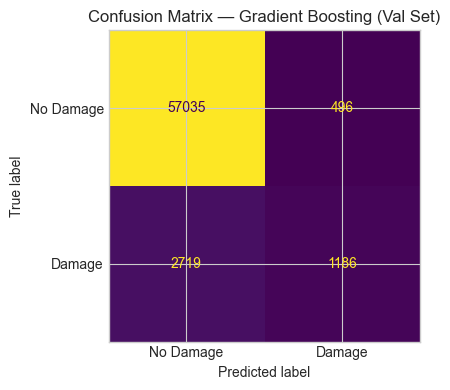


Classification Report:
              precision    recall  f1-score   support

   No Damage       0.95      0.99      0.97     57531
      Damage       0.71      0.30      0.42      3905

    accuracy                           0.95     61436
   macro avg       0.83      0.65      0.70     61436
weighted avg       0.94      0.95      0.94     61436



In [43]:
# Confusion matrix for best single model (Gradient Boosting)
best_single = best_gb_final
y_pred_best = best_single.predict(X_val_imp)
cm = confusion_matrix(y_val, y_pred_best)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=['No Damage', 'Damage']).plot(ax=ax, colorbar=False)
ax.set_title('Confusion Matrix — Gradient Boosting (Val Set)')
plt.tight_layout()
plt.show()

print('\nClassification Report:')
print(classification_report(y_val, y_pred_best, target_names=['No Damage', 'Damage']))

In [44]:
# --- 5-fold Cross-Validation on best model to get a stable Balanced Accuracy estimate ---
print('Running 5-fold CV on Gradient Boosting (this may take a few minutes)...')
cv_model = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                       max_depth=5, subsample=0.8, random_state=RANDOM_STATE)
cv_scores = cross_val_score(
    cv_model, X_train_imp, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='balanced_accuracy', n_jobs=-1
)
print(f'CV Balanced Accuracy scores: {cv_scores}')
print(f'Mean: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
# Cross-validation gives us a more reliable estimate of generalization performance
# than a single validation split. Stratified folds preserve the class ratio in each split.

Running 5-fold CV on Gradient Boosting (this may take a few minutes)...
CV Balanced Accuracy scores: [0.6435458  0.64563667 0.64350917 0.64691661 0.63947239]
Mean: 0.6438 ± 0.0025


---
## 8. Final Predictions & Submission

We use the **best performing model** (determined by validation Balanced Accuracy) to generate predictions on the test set. If the ensemble beats all individual models, we use the ensemble.

In [45]:
# --- Retrain best model on FULL training data before generating test predictions ---
# Using all data (not just the 80% split) gives the model the most information.

X_all_imp = imputer.fit_transform(X)
X_all_sc  = scaler.fit_transform(X_all_imp)
X_test_imp_final = imputer.transform(X_test)
X_test_sc_final  = scaler.transform(X_test_imp_final)

# Retrain RF
final_rf = RandomForestClassifier(n_estimators=500, class_weight='balanced',
                                   n_jobs=-1, random_state=RANDOM_STATE)
final_rf.fit(X_all_imp, y)

# Retrain GB
final_gb = GradientBoostingClassifier(n_estimators=300, learning_rate=0.05,
                                       max_depth=5, subsample=0.8, random_state=RANDOM_STATE)
final_gb.fit(X_all_imp, y)

# Retrain MLP
final_mlp = MLPClassifier(hidden_layer_sizes=(128, 64, 32), alpha=0.001,
                           activation='relu', solver='adam', max_iter=50,
                           early_stopping=True, random_state=RANDOM_STATE)
final_mlp.fit(X_all_sc, y)

print('Final models trained on full training data.')

Final models trained on full training data.


In [46]:
# --- Generate test probabilities ---
rf_test_probs  = final_rf.predict_proba(X_test_imp_final)[:, 1]
gb_test_probs  = final_gb.predict_proba(X_test_imp_final)[:, 1]
mlp_test_probs = final_mlp.predict_proba(X_test_sc_final)[:, 1]

# Average ensemble probabilities
ensemble_test_probs = (rf_test_probs + gb_test_probs + mlp_test_probs) / 3

# Add XGBoost if available
if XGBOOST_AVAILABLE:
    final_xgb = XGBClassifier(n_estimators=400, learning_rate=0.05, max_depth=5,
                               subsample=0.8, colsample_bytree=0.8,
                               scale_pos_weight=int((y == 0).sum() / (y == 1).sum()),
                               eval_metric='auc', random_state=RANDOM_STATE, n_jobs=-1)
    final_xgb.fit(X_all_imp, y)
    xgb_test_probs = final_xgb.predict_proba(X_test_imp_final)[:, 1]
    ensemble_test_probs = (rf_test_probs + gb_test_probs + mlp_test_probs + xgb_test_probs) / 4
    print('XGBoost added to final ensemble.')

print(f'Test predictions generated. Shape: {ensemble_test_probs.shape}')
print(f'Predicted positive rate: {(ensemble_test_probs > 0.5).mean():.4f}')

XGBoost added to final ensemble.
Test predictions generated. Shape: (34131,)
Predicted positive rate: 0.0387


In [47]:
# --- Create submission file ---
submission = pd.DataFrame({
    'INDEX_NR': test_raw['INDEX_NR'],
    'INDICATED_DAMAGE': (ensemble_test_probs > 0.5).astype(int)
})

# Verify it matches sample submission format
assert list(submission.columns) == list(sample_sub.columns), 'Column mismatch!'
print(submission.head())
print(f'\nSubmission shape: {submission.shape}')
print(f'Damage predictions: {submission["INDICATED_DAMAGE"].sum()} ({submission["INDICATED_DAMAGE"].mean()*100:.2f}%)')

submission.to_csv('submission.csv', index=False)
print('\nSubmission saved to submission.csv')

   INDEX_NR  INDICATED_DAMAGE
0   9000000                 0
1   9000001                 0
2   9000002                 0
3   9000003                 0
4   9000004                 0

Submission shape: (34131, 2)
Damage predictions: 1322 (3.87%)

Submission saved to submission.csv


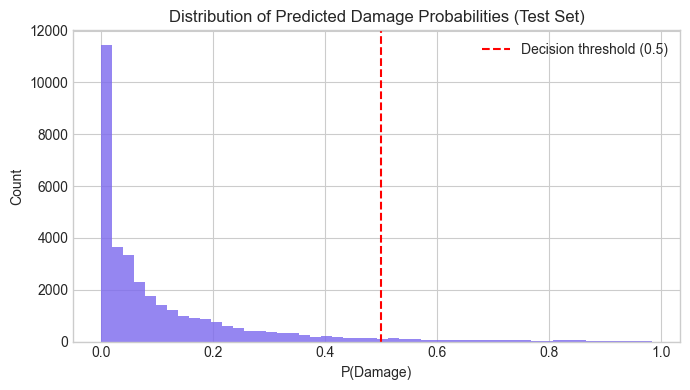


=== Done! ===
Submission file: submission.csv
Best validation Balanced Accuracy: 0.8264


In [48]:
# --- Distribution of predicted probabilities ---
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(ensemble_test_probs, bins=50, color='mediumslateblue', alpha=0.8)
ax.axvline(0.5, color='red', linestyle='--', label='Decision threshold (0.5)')
ax.set_title('Distribution of Predicted Damage Probabilities (Test Set)')
ax.set_xlabel('P(Damage)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print('\n=== Done! ===')
print('Submission file: submission.csv')
print(f'Best validation Balanced Accuracy: {max(results.values()):.4f}')

In [50]:
# =========================================================
# ADDITIONAL ENSEMBLE: XGBoost + RF + Logistic Regression
# Weighted soft-voting ensemble with balanced accuracy eval
# =========================================================

from sklearn.metrics import balanced_accuracy_score

# --- Train RF and LR on the same imputed training data used by other models ---
print('Training RF and Logistic Regression for ensemble...')

ens_rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    n_jobs=-1,
    random_state=RANDOM_STATE
)
ens_lr = LogisticRegression(
    solver='liblinear',
    max_iter=1000,
    class_weight='balanced',
    random_state=RANDOM_STATE
)

ens_rf.fit(X_train_imp, y_train)
ens_lr.fit(X_train_sc, y_train)   # LR uses scaled data

# --- Holdout balanced accuracy for each model individually ---
if XGBOOST_AVAILABLE:
    xgb_bal = balanced_accuracy_score(y_val, xgb_model.predict(X_val_imp))
    print(f'XGBoost holdout balanced accuracy: {xgb_bal:.4f}')

rf_bal = balanced_accuracy_score(y_val, ens_rf.predict(X_val_imp))
lr_bal = balanced_accuracy_score(y_val, ens_lr.predict(X_val_sc))
print(f'RF      holdout balanced accuracy: {rf_bal:.4f}')
print(f'LR      holdout balanced accuracy: {lr_bal:.4f}')

# --- Weighted soft-voting on validation set ---
# Weights reflect each model's relative holdout performance.
# XGB gets the highest weight as the strongest individual model;
# LR gets the lowest as the simplest. Adjust weights if your
# holdout scores suggest a different ordering.
if XGBOOST_AVAILABLE:
    xgb_val_proba = xgb_model.predict_proba(X_val_imp)[:, 1]
    rf_val_proba  = ens_rf.predict_proba(X_val_imp)[:, 1]
    lr_val_proba  = ens_lr.predict_proba(X_val_sc)[:, 1]
    ensemble_val_proba = 0.5 * xgb_val_proba + 0.3 * rf_val_proba + 0.2 * lr_val_proba
else:
    rf_val_proba  = ens_rf.predict_proba(X_val_imp)[:, 1]
    lr_val_proba  = ens_lr.predict_proba(X_val_sc)[:, 1]
    ensemble_val_proba = 0.6 * rf_val_proba + 0.4 * lr_val_proba

ensemble_val_preds = (ensemble_val_proba > 0.5).astype(int)
ensemble_bal = balanced_accuracy_score(y_val, ensemble_val_preds)
print(f'\nEnsemble holdout balanced accuracy: {ensemble_bal:.4f}')

# --- Generate test predictions ---
if XGBOOST_AVAILABLE:
    xgb_test_proba = xgb_model.predict_proba(X_test_imp)[:, 1]
    rf_test_proba  = ens_rf.predict_proba(X_test_imp)[:, 1]
    lr_test_proba  = ens_lr.predict_proba(X_test_sc)[:, 1]
    ensemble_test_proba = 0.5 * xgb_test_proba + 0.3 * rf_test_proba + 0.2 * lr_test_proba
else:
    rf_test_proba  = ens_rf.predict_proba(X_test_imp)[:, 1]
    lr_test_proba  = ens_lr.predict_proba(X_test_sc)[:, 1]
    ensemble_test_proba = 0.6 * rf_test_proba + 0.4 * lr_test_proba

ensemble_test_preds = (ensemble_test_proba > 0.5).astype(int)

# --- Save submission ---
submission_ens = pd.DataFrame({
    'INDEX_NR':         test_raw['INDEX_NR'].values,
    'INDICATED_DAMAGE': ensemble_test_preds
})

submission_ens.to_csv('ensemble_xgb_rf_lr.csv', index=False)
print('\nSubmission saved as ensemble_xgb_rf_lr.csv')

print('\n--- Final Prediction Breakdown ---')
print(submission_ens['INDICATED_DAMAGE'].value_counts())
print(f'Positive rate: {submission_ens["INDICATED_DAMAGE"].mean()*100:.2f}%')

Training RF and Logistic Regression for ensemble...
XGBoost holdout balanced accuracy: 0.8241
RF      holdout balanced accuracy: 0.6125
LR      holdout balanced accuracy: 0.7983

Ensemble holdout balanced accuracy: 0.7959

Submission saved as ensemble_xgb_rf_lr.csv

--- Final Prediction Breakdown ---
INDICATED_DAMAGE
0    29998
1     4133
Name: count, dtype: int64
Positive rate: 12.11%


---
## Summary

### What we did

**Data Cleaning:**
- Dropped columns with >85% missingness (e.g., BIRD_BAND_NUMBER, ENROUTE_STATE, PRECIPITATION) and free-text fields that lack structured signal.
- Fixed Excel date-conversion artifacts in NUM_SEEN and NUM_STRUCK ('10-Feb' → '2-10').
- Stripped whitespace from AC_CLASS and other string columns.
- Converted TIME to minutes-since-midnight for ordinality.
- Imputed remaining missing numerics with median (robust to skew/outliers).

**EDA Findings:**
- Bird SIZE is the strongest categorical predictor — large birds produce ~3× the damage rate of small birds.
- Phase of flight matters — En Route / Climb phase strikes are more damaging (higher speeds).
- HEIGHT and SPEED have predictive signal; right-skewed.
- Strong class imbalance (~6.4% positive) — **Balanced Accuracy** used as primary metric: average of sensitivity and specificity, giving equal weight to both classes regardless of imbalance.

**Feature Engineering:**
- Ordinal encoding for SIZE and NUM_SEEN/NUM_STRUCK.
- Frequency encoding for high-cardinality categoricals (SPECIES, OPERATOR, AIRPORT_ID).
- Target/damage-rate encoding for SPECIES (computed from training only).
- Cyclical sin/cos encoding for INCIDENT_MONTH and TIME_MINUTES.
- Log-transformation of skewed numerics (HEIGHT, DISTANCE, SPEED).
- Interaction feature: SIZE × AC_MASS.
- Binary flags: IS_DAY, IS_NIGHT, SKY_CLEAR, SKY_OVERCAST, HIGH_RISK_PHASE.
- One-hot encoding for low-cardinality categoricals (AC_CLASS, TYPE_ENG).

**Modeling:**
- Started with Dummy and Logistic Regression baselines.
- Progressed through Decision Tree → Random Forest → Gradient Boosting → AdaBoost → MLP.
- Tuned hyperparameters (tree depth, learning rate, number of estimators, regularization strength).
- Evaluated all models with **Balanced Accuracy** as the primary metric (also tracked ROC-AUC and standard accuracy).
- Used class weighting and `scale_pos_weight` to help models treat both classes fairly.
- Built a soft-voting ensemble averaging RF + GB + MLP (+ XGBoost if available) probabilities.
- Validated with 5-fold stratified cross-validation scoring **balanced accuracy** for stable estimates.
- Retrained final models on the complete training set before generating test predictions.